In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight

In [3]:
data = pd.read_csv('customer_data.csv')

features = [col for col in data.columns if col not in ['label', 'id']]
X = data[features].values
y = data['label'].values

In [4]:
print(data.isnull().sum())
print(data[features].isnull().sum().sum())
print(data.head(5))

label       0
id          0
fea_1       0
fea_2     149
fea_3       0
fea_4       0
fea_5       0
fea_6       0
fea_7       0
fea_8       0
fea_9       0
fea_10      0
fea_11      0
dtype: int64
149
   label        id  fea_1   fea_2  fea_3     fea_4  fea_5  fea_6  fea_7  \
0      1  54982665      5  1245.5      3   77000.0      2     15      5   
1      0  59004779      4  1277.0      1  113000.0      2      8     -1   
2      0  58990862      7  1298.0      1  110000.0      2     11     -1   
3      1  58995168      7  1335.5      1  151000.0      2     11      5   
4      0  54987320      7     NaN      2   59000.0      2     11      5   

   fea_8  fea_9  fea_10      fea_11  
0    109      5  151300  244.948974  
1    100      3  341759  207.173840  
2    101      5   72001    1.000000  
3    110      3   60084    1.000000  
4    108      4  450081  197.403141  


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify = y)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

clf = LogisticRegression(class_weight="balanced",random_state=42, max_iter= 1000, C=0.1).fit(X_train_scaled, y_train)
predict = clf.predict(X_test_scaled)

probabilities = clf.predict_proba(X_test_scaled)

clf.score(X_test_scaled, y_test)

0.5177304964539007

In [6]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.83      0.50      0.62       226
           1       0.23      0.59      0.33        56

    accuracy                           0.52       282
   macro avg       0.53      0.54      0.48       282
weighted avg       0.71      0.52      0.57       282



In [7]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

clf = SVC(C=750.0, class_weight='balanced', random_state=42).fit(X_train_scaled, y_train)
predict = clf.predict(X_test_scaled)
clf.score(X_test_scaled, y_test)

0.6773049645390071

In [8]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       226
           1       0.24      0.29      0.26        56

    accuracy                           0.68       282
   macro avg       0.53      0.53      0.53       282
weighted avg       0.70      0.68      0.69       282



In [124]:
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0025)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0025)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.0025)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

Epoch 1/200
22/22 - 8s - 383ms/step - accuracy: 0.6306 - loss: 1.0713 - val_accuracy: 0.6923 - val_loss: 1.0248
Epoch 2/200
22/22 - 0s - 6ms/step - accuracy: 0.6009 - loss: 1.0492 - val_accuracy: 0.5976 - val_loss: 1.0181
Epoch 3/200
22/22 - 0s - 6ms/step - accuracy: 0.5549 - loss: 1.0251 - val_accuracy: 0.5680 - val_loss: 1.0205
Epoch 4/200
22/22 - 0s - 6ms/step - accuracy: 0.5341 - loss: 1.0100 - val_accuracy: 0.5740 - val_loss: 0.9986
Epoch 5/200
22/22 - 0s - 6ms/step - accuracy: 0.5727 - loss: 0.9990 - val_accuracy: 0.5621 - val_loss: 0.9903
Epoch 6/200
22/22 - 0s - 6ms/step - accuracy: 0.5757 - loss: 0.9821 - val_accuracy: 0.5976 - val_loss: 0.9797
Epoch 7/200
22/22 - 0s - 6ms/step - accuracy: 0.5682 - loss: 0.9649 - val_accuracy: 0.5976 - val_loss: 0.9665
Epoch 8/200
22/22 - 0s - 6ms/step - accuracy: 0.5712 - loss: 0.9614 - val_accuracy: 0.6036 - val_loss: 0.9476
Epoch 9/200
22/22 - 0s - 8ms/step - accuracy: 0.5727 - loss: 0.9386 - val_accuracy: 0.5680 - val_loss: 0.9490
Epoch 10

In [125]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.82      0.63      0.71       226
           1       0.23      0.45      0.30        56

    accuracy                           0.60       282
   macro avg       0.53      0.54      0.51       282
weighted avg       0.70      0.60      0.63       282

ROC-AUC: 0.5755372945638432


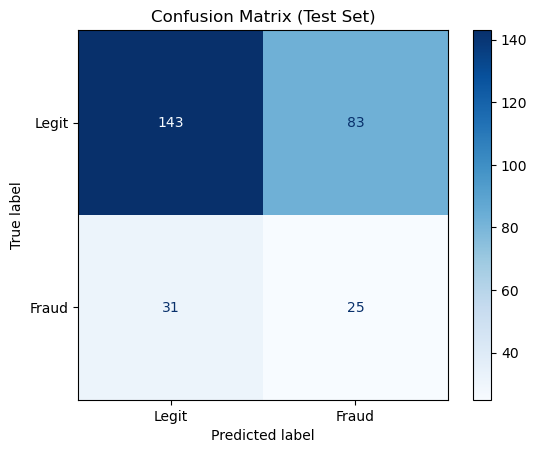

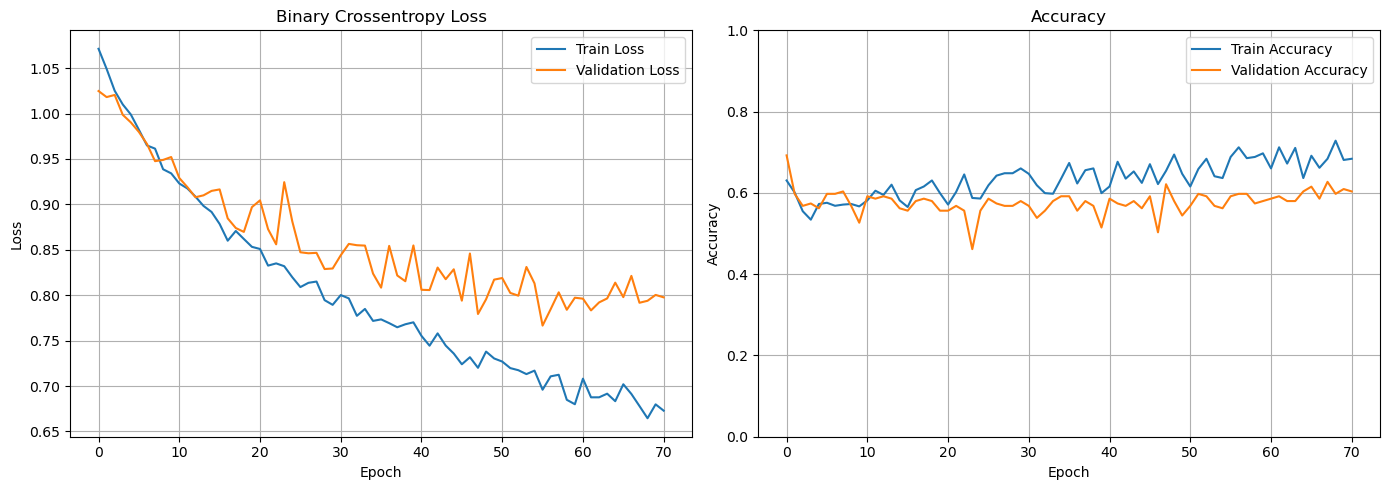

In [126]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test Set)")
plt.show()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Binary Crossentropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()